# Cu Nanoparticles in situ formation in LDPE

## Set_up()

In [2]:
%run ../../../setup_workspace.py # ../ means level up 

# Data

In [3]:
poni_saxs = r"E:\Nps Cu\IHSC 1872\SAXS_1p4m_12keV.poni"
ai_saxs = pyFAI.load(poni_saxs)

poni_waxs = r"E:\Nps Cu\IHSC 1872\WAXS_1p4m_12keV.poni"
ai_waxs = pyFAI.load(poni_waxs)

mask_saxs = r"E:\Nps Cu\IHSC 1872\MASK_SAXS_1p4m_12keV.edf"
img_mask_saxs = fabio.open(mask_saxs).data

mask_waxs = r"E:\Nps Cu\IHSC 1872\MASK_WAXS_1p4m_12keV.edf"
img_mask_waxs = fabio.open(mask_waxs).data

##### Cu 0.5%

In [4]:
path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_05_heat = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Isoth_190C_30min'
Cu_05_iso = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_aftertrans\CuPE_0_5perc_1_4m_aftertrans_RT_measurement'
Cu_05_after = BM26_experiment(path)

##### Cu 3%

In [5]:
path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_3_heat = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Isoth_190C'
Cu_3_iso = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_aftertrans\CuPE_3perc_1_4m_aftertrans_RT_measurement'
Cu_3_after = BM26_experiment(path)

In [6]:
Time_3_iso = Cu_3_iso.get_Time_profile()
Temp_3_iso = Cu_3_iso.get_T_profile()
Time_3_heat = Cu_3_heat.get_Time_profile()
Temp_3_heat = Cu_3_heat.get_T_profile()

Found 60 EDF files in SAXS
Found 89 EDF files in SAXS


In [7]:
Time_05_iso = Cu_05_iso.get_Time_profile()
Temp_05_iso = Cu_05_iso.get_T_profile()
Time_05_heat = Cu_05_heat.get_Time_profile()
Temp_05_heat = Cu_05_heat.get_T_profile()

Found 66 EDF files in SAXS
Found 88 EDF files in SAXS


# Functions

In [8]:
def Guinier(q, I_0, R_g):
    return I_0 * np.exp(-q ** 2 * R_g ** 2 / 3)

def norm_saxs(q, I_array):
    for i in range(len(I_array)):
        I = I_array[i]
        I /= np.mean(I[(q>3)*(q<3.3)])
    #return q, I

def norm_waxs(q, I_array):
    for i in range(len(I_array)):
        I = I_array[i]
        I /= np.mean(I[(q>20)*(q<20.5)])
    #return q, I

def Invariant(q, I):
    l = 0.15
    r = 1.5
    x = q[(q>l)*(q<r)]
    y = I[(q>l)*(q<r)] - 1
    return np.trapezoid(y*x**2, x=x)

import scipy
def Polydisperse_spheres(x, scale, Ravg, p, bkg):
    global sigma
    sigma = p*Ravg
    ro = scale
    R = np.arange(max((Ravg - 3*sigma), 0.00001), Ravg + 3*sigma, 0.05)
    Iq = []
    for i in x:
        f = (Gaussian(R, sigma, Ravg) * (R**6)) * ((3*(np.sin(i*R) - i*R*np.cos(i*R))/(i*R)**3)**2)
        Iq.append(((4*np.pi / 3)**2) * (ro**2) * scipy.integrate.cumulative_trapezoid(f, R, dx = None, axis = 0)[-1] + bkg)
    #f = np.array(f)
    return Iq

def linear(x, a, b):
    return a * x + b

# Analysis

##### style

In [9]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 20
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.tt'] = 'Arial'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

### SAXS

In [10]:
q_SAXS, I_SAXS_3_heat = Cu_3_heat.integrate1d_SAXS(ai_saxs, 1000, mask=img_mask_saxs, unit='q_nm^-1')
norm_saxs(q_SAXS, I_SAXS_3_heat)

q_SAXS, I_SAXS_3_iso = Cu_3_iso.integrate1d_SAXS(ai_saxs, 1000, mask=img_mask_saxs, unit='q_nm^-1')
norm_saxs(q_SAXS, I_SAXS_3_iso)

In [11]:
q_SAXS, I_SAXS_05_heat = Cu_05_heat.integrate1d_SAXS(ai_saxs, 1000, mask=img_mask_saxs, unit='q_nm^-1')
norm_saxs(q_SAXS, I_SAXS_05_heat)

q_SAXS, I_SAXS_05_iso = Cu_05_iso.integrate1d_SAXS(ai_saxs, 1000, mask=img_mask_saxs, unit='q_nm^-1')
norm_saxs(q_SAXS, I_SAXS_05_iso)

##### Guinier

In [12]:
Cu_3_heat.get_T_profile()[70]

Found 89 EDF files in SAXS


np.float64(163.3)

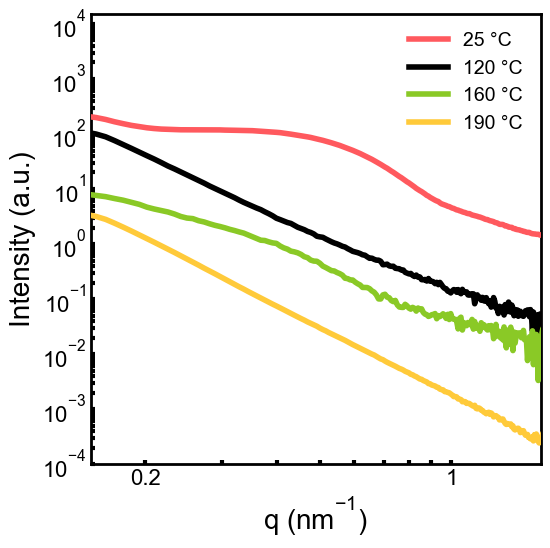

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))

K = 0.99

q = q_SAXS
I1 = I_SAXS_05_iso
I2 = I_SAXS_05_heat

ax.plot(q, I2[0], linewidth=4, label='25 °C', color='#ff595e', zorder=10)
ax.plot(q, I2[45] - 1.01, linewidth=4, label='120 °C', color='black', zorder=1)
ax.plot(q, (I2[70] - K * I2[45]) / 3, linewidth=4, label='160 °C', color='#8ac926', zorder=8)
ax.plot(q, (I1[-1] -  K * I2[45]) / 500, linewidth=4, label='190 °C', color='#ffca3a', zorder=9)

# ax.plot(q, I2[75] - K * I2[45], linewidth=4, label='Heat (174 °C)',color='#1982c4', zorder=7)

# ax.plot(q, I2[70] - K * I2[45], linewidth=4, label='Heat (164 °C)', color='#6a4c93', zorder=6)



# lnsp = np.linspace(0.25, 0.4, 1000)
# plt.plot(lnsp, lnsp**-4 / 1500, color='black', linewidth=2)
# plt.plot(lnsp, np.ones(1000) * min(lnsp**-4 / 1500), color='black', linewidth=2)
# plt.plot(np.ones(1000)*lnsp[0], lnsp**-4 / 1500, color='black',linewidth=2)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.15, 1.6)
ax.set_ylim(0.1e-3, 1.5e4)
ax.set_xticks([0.2, 1])
ax.set_xticklabels(['0.2', '1'])

# Легенда
ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
    
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

# ax.text(0.05, 0.97, 'a)', transform=ax.transAxes, fontsize=24, #fontweight='bold', 
#          fontfamily='Arial', verticalalignment='top', horizontalalignment='left')

ax.set_position([0.15, 0.15, 0.75, 0.75])
plt.savefig(r'E:\Nps Cu\Figures\Fig_proposal.png', dpi=300, bbox_inches='tight', transparent=True)

R_g =  11.166059245893987
q * R_g 1.8995668091261642
R_g =  2.44307195375091
q * R_g 2.8201918174655116


C:\Users\LabPCA\AppData\Local\Temp\ipykernel_14816\3493402393.py:2: RuntimeWarning: invalid value encountered in log
  Y = np.log(I_SAXS_05_iso[-1] - I_SAXS_05_heat[45])


(-1.0, 8.0)

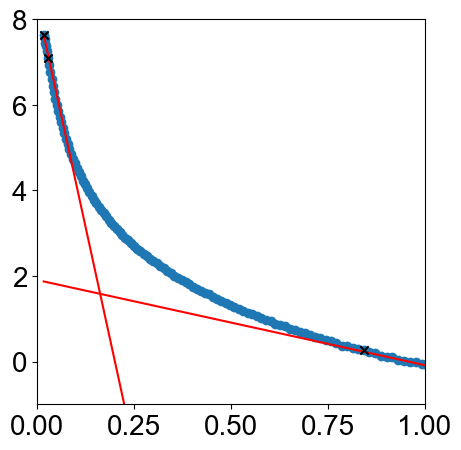

In [14]:
plt.figure(figsize=(5,5))
Y = np.log(I_SAXS_05_iso[-1] - I_SAXS_05_heat[45])
X = q_SAXS ** 2

plt.scatter(X, Y)

left = 0
right = 5

plt.scatter([X[left], X[right]], [Y[left], Y[right]], marker='x', zorder=10, color='black')
p, cov = curve_fit(linear, X[left:right], Y[left:right])

plt.plot(X, linear(X, *p), color='red')
R_g = np.sqrt(-p[0] * 3)
print('R_g = ', R_g)
print('q * R_g', np.sqrt(X[right]) * R_g)

left = 100
right = 130


plt.scatter([X[left], X[right]], [Y[left], Y[right]], marker='x', zorder=10, color='black')
p, cov = curve_fit(linear, X[left:right], Y[left:right])

plt.plot(X, linear(X, *p), color='red')
R_g = np.sqrt(-p[0] * 3)
print('R_g = ', R_g)
print('q * R_g', np.sqrt(X[right]) * R_g)

plt.xlim(0, 1)
plt.ylim(-1, 8)

[]

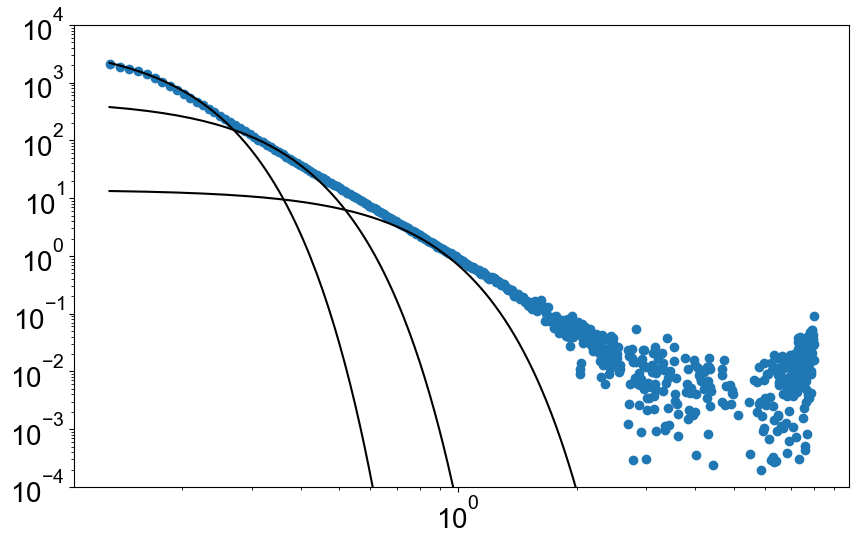

In [15]:

plt.scatter(q_SAXS,  I_SAXS_05_iso[-1] - I_SAXS_05_heat[45])

plt.plot(q_SAXS, Guinier(q_SAXS, 5e3, 12), zorder=10, color='black')
plt.plot(q_SAXS, Guinier(q_SAXS, 5e2, 7), zorder=10, color='black')
plt.plot(q_SAXS, Guinier(q_SAXS, 1.4e1, 3), zorder=10, color='black')

plt.ylim(1e-4, 1e4)
plt.semilogx()
plt.semilogy()

##### Invariant



In [16]:
def Model(x, I_p, p, I_g, R_g):
    return Guinier(x, I_g, R_g) + I_p * x ** -p

1.0215319409137174
7.798934715906449


(np.float64(0.38380378748855043), np.float64(63.21706754692246))

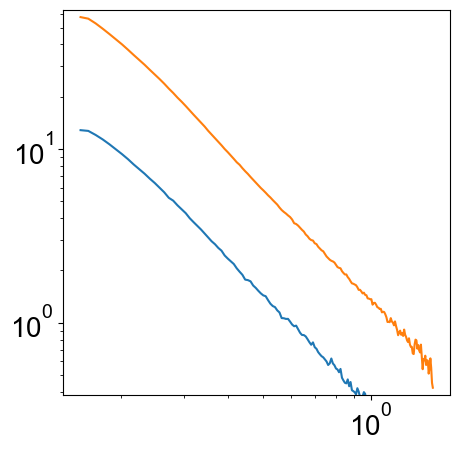

In [17]:
l = 0.15
r = 1.5
q = q_SAXS

I_bkg = I_SAXS_3_heat[45] 

plt.figure(figsize=(5,5))

I = I_SAXS_3_iso[0] - I_bkg 

x = q[(q>l)*(q<r)]
y = I[(q>l)*(q<r)] * x ** 2 

print(Invariant(q, I))
plt.plot(x, y)

I = I_SAXS_3_iso[40] - I_bkg 

x = q[(q>l)*(q<r)]
y = I[(q>l)*(q<r)] * x ** 2 

print(Invariant(q, I))
plt.plot(x, y)

# p, cov= curve_fit(Model, x, y, bounds=((0,-np.inf,0,0), (np.inf, 0, np.inf, np.inf)), p0=[1,-4, 100, 15])

# plt.plot(x, Model(x, *p), linestyle='--')
# plt.plot(x,  Guinier(x, p[2], p[3]) )
# plt.plot(x,  p[0] * x ** - p[1] )
# print(np.trapezoid(y, x=x))

plt.semilogx()
plt.semilogy()

plt.ylim(min(y) / 1.1, max(y) * 1.1)

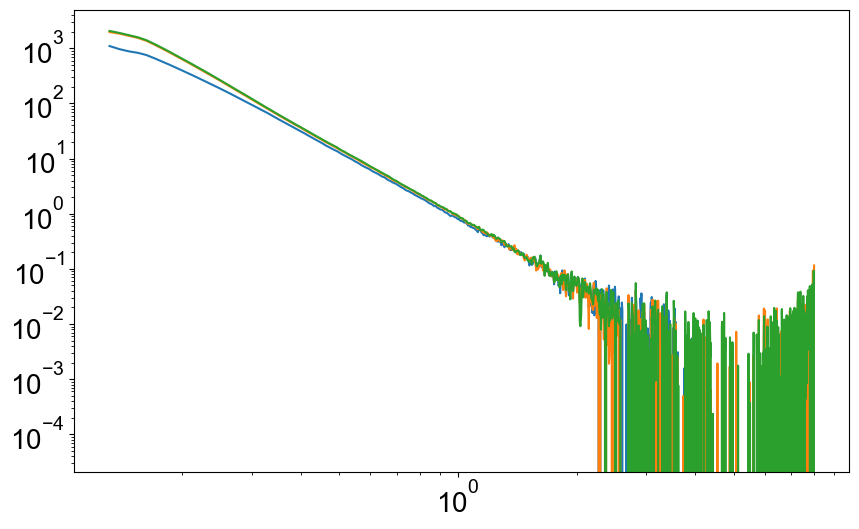

In [18]:
plt.semilogx()
plt.semilogy()

plt.plot(q, I_SAXS_05_iso[0] - I_SAXS_05_heat[45])
plt.plot(q, I_SAXS_05_iso[50]- I_SAXS_05_heat[45])
plt.plot(q, I_SAXS_05_iso[-1]- I_SAXS_05_heat[45])

In [19]:
def Invariant(q, I):
    
    l = 0.15
    r = 1.5
    x = q[(q>l)*(q<r)]
    y = I[(q>l)*(q<r)]
    return np.trapezoid(y*x**2, x=x)


In [20]:
Invariant_3 = []

for i in range(89):
    q = q_SAXS
    I =  I_SAXS_3_heat[i] - I_SAXS_3_heat[45]
    Invariant_3.append(Invariant(q, I))

for i in range(60):
    q = q_SAXS
    I =  I_SAXS_3_iso[i] - I_SAXS_3_heat[45]
    Invariant_3.append(Invariant(q, I))

Invariant_05 = []

for i in range(88):
    q = q_SAXS
    I =  I_SAXS_05_heat[i] - I_SAXS_05_heat[45]
    Invariant_05.append(Invariant(q, I))

for i in range(66):
    q = q_SAXS
    I =  I_SAXS_05_iso[i] - I_SAXS_05_heat[45]
    Invariant_05.append(Invariant(q, I)) 

# Invariant_05 -= min(Invariant_05)
# Invariant_3 -= min(Invariant_3)

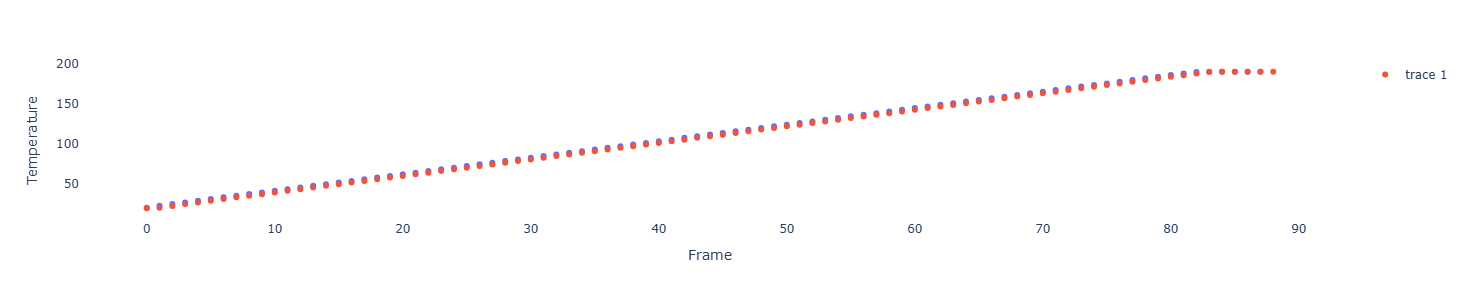

In [21]:
import plotly.express as px

fig = px.scatter(x=list(range(len(Temp_05_heat))), y=Temp_05_heat)
fig.add_scatter(x=list(range(len(Temp_3_heat))), y=Temp_3_heat, mode='markers')
fig.update_layout(
    width=500, 
    height=300,
    xaxis_title='Frame',
    yaxis_title='Temperature',
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig.show()

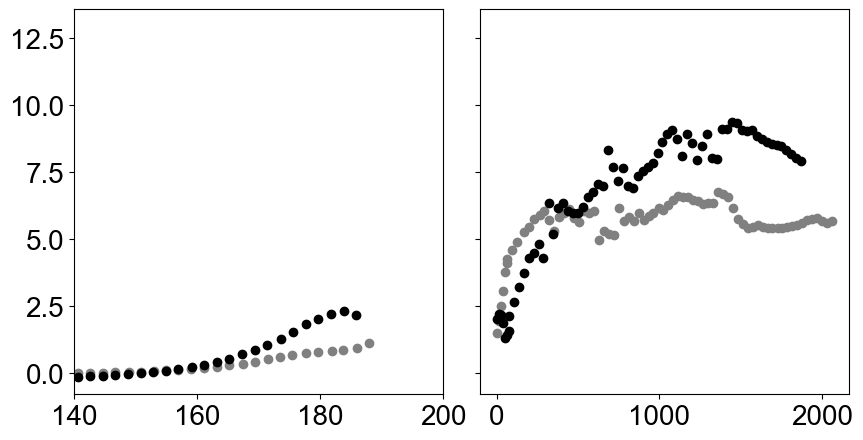

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax1.scatter(Temp_05_heat[:82], Invariant_05[:82], color='grey')
ax2.scatter(Time_05_heat[82:] - Time_05_heat[82], Invariant_05[82:88], color='grey')
ax2.scatter(Time_05_iso + Time_05_heat[87] - Time_05_heat[82], Invariant_05[88:], color='grey')

ax1.scatter(Temp_3_heat[:82], Invariant_3[:82], color='black')
ax2.scatter(Time_3_heat[82:] - Time_3_heat[82], Invariant_3[82:89], color='black')
ax2.scatter(Time_3_iso + Time_3_heat[88] - Time_3_heat[82], Invariant_3[89:], color='black')

ax1.set_xlim(140, 200)
plt.subplots_adjust(wspace=0.1)  # уменьшаем расстояние между графиками

### WAXS

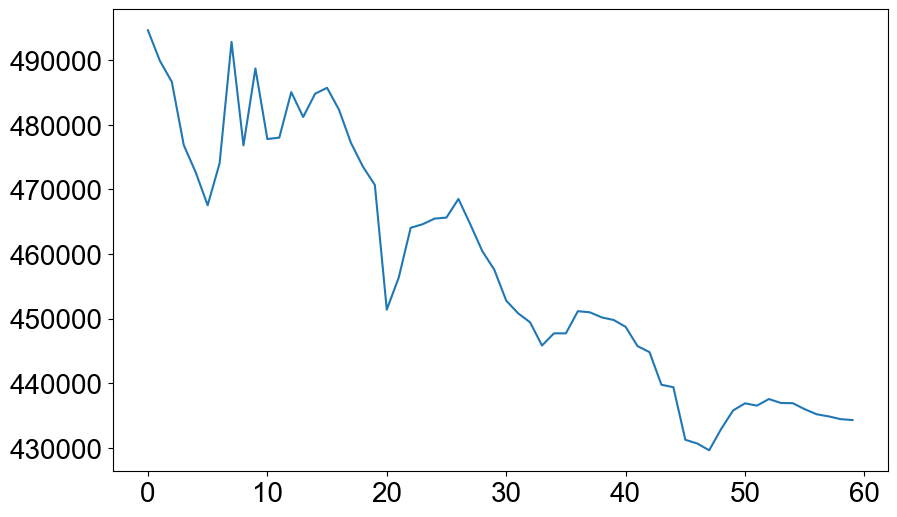

In [23]:
plt.plot(Cu_3_iso.get_Photo())

In [24]:
q_WAXS, I_WAXS_3_heat = Cu_3_heat.integrate1d_WAXS(ai_waxs, 1000, mask=img_mask_waxs, unit='q_nm^-1')
norm_waxs(q_WAXS, I_WAXS_3_heat)

q_WAXS, I_WAXS_3_iso = Cu_3_iso.integrate1d_WAXS(ai_waxs, 1000, mask=img_mask_waxs, unit='q_nm^-1')
norm_waxs(q_WAXS, I_WAXS_3_iso)

In [25]:
q_WAXS, I_WAXS_05_heat = Cu_05_heat.integrate1d_WAXS(ai_waxs, 1000, mask=img_mask_waxs, unit='q_nm^-1')
norm_waxs(q_WAXS, I_WAXS_05_heat)

q_WAXS, I_WAXS_05_iso = Cu_05_iso.integrate1d_WAXS(ai_waxs, 1000, mask=img_mask_waxs, unit='q_nm^-1')
norm_waxs(q_WAXS, I_WAXS_05_iso)

In [26]:
I_111_3 = []

for i in range(89):
    I_111_3.append(I_WAXS_3_heat[i][553])

for i in range(60):
    I_111_3.append(I_WAXS_3_iso[i][553])    

I_111_05 = []

for i in range(88):
    I_111_05.append(I_WAXS_05_heat[i][552])

for i in range(66):
    I_111_05.append(I_WAXS_05_iso[i][552])    

# Figures

### Fig 1a

In [27]:
Temp_3_heat[84]

np.float64(190.1)

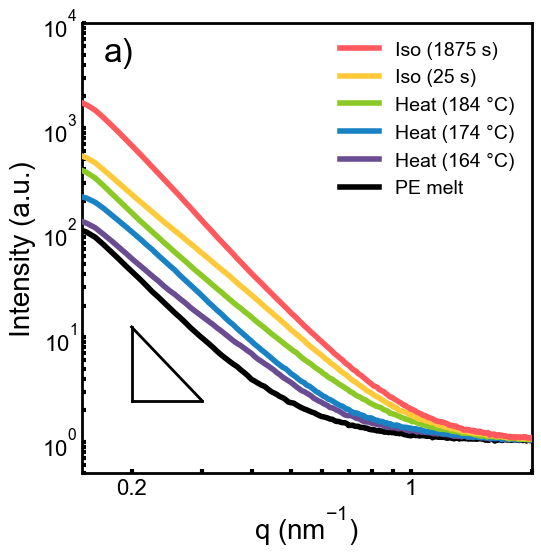

In [28]:
fig, ax = plt.subplots(figsize=(6, 6))

K = 0

q = q_SAXS
I1 = I_SAXS_05_iso
I2 = I_SAXS_05_heat

ax.plot(q, I1[59] -  K * I2[45], linewidth=4, label='Iso (1875 s)', color='#ff595e', zorder=10)
ax.plot(q, I2[84] -  K * I2[45], linewidth=4, label='Iso (25 s)', color='#ffca3a', zorder=9)

ax.plot(q, I2[82] - K * I2[45], linewidth=4, label='Heat (184 °C)', color='#8ac926', zorder=8)

ax.plot(q, I2[75] - K * I2[45], linewidth=4, label='Heat (174 °C)',color='#1982c4', zorder=7)

ax.plot(q, I2[70] - K * I2[45], linewidth=4, label='Heat (164 °C)', color='#6a4c93', zorder=6)

ax.plot(q, I2[45] - K * I2[45] , linewidth=4, label='PE melt', color='black', zorder=1)


lnsp = np.linspace(0.2, 0.3, 1000)
plt.plot(lnsp, lnsp**-4 / 50, color='black', linewidth=2)
plt.plot(lnsp, np.ones(1000) * min(lnsp**-4 / 50), color='black', linewidth=2)
plt.plot(np.ones(1000)*lnsp[0], lnsp**-4 / 50, color='black',linewidth=2)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.15, 2)
ax.set_ylim(0.5, 1e4)
ax.set_xticks([0.2, 1])
ax.set_xticklabels(['0.2', '1'])

# Легенда
ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
    
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

ax.text(0.05, 0.97, 'a)', transform=ax.transAxes, fontsize=24, #fontweight='bold', 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left')

ax.set_position([0.15, 0.15, 0.75, 0.75])
plt.savefig(r'E:\Nps Cu\Figures\Fig1_a.png', dpi=300, bbox_inches='tight', transparent=True)


### Fig 1b

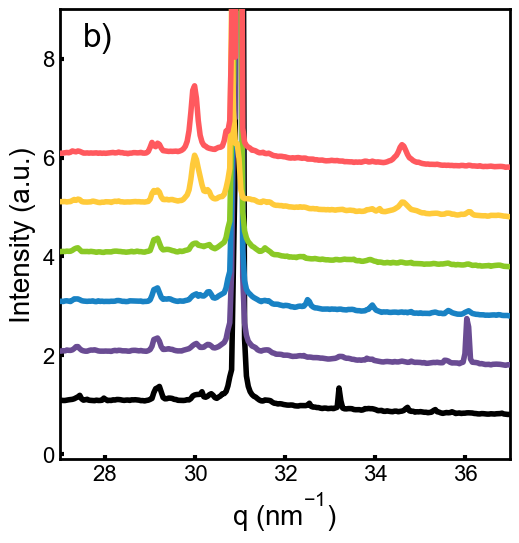

In [140]:
fig, ax = plt.subplots(figsize=(6, 6))

K = 1

q = q_WAXS
I1 = I_WAXS_05_iso
I2 = I_WAXS_05_heat

ax.plot(q, I1[59]  + 5 * K, linewidth=4, label='Iso (1800 s)', color='#ff595e', zorder=10)
p = 553
#plt.scatter(q[p], I_3_iso[59][p] + 5 * K, marker = 'x', s=200, color='black', zorder=100)

ax.plot(q, I1[5]  + 4 * K, linewidth=4, label='Iso (150 s)', color='#ffca3a', zorder=9)

ax.plot(q, I2[80]  + 3 * K, linewidth=4, label='Heat (184 °C)', color='#8ac926', zorder=8)

ax.plot(q, I2[75] + 2 * K, linewidth=4, label='Heat (174 °C)',color='#1982c4', zorder=7)

ax.plot(q, I2[70] + K, linewidth=4, label='Heat (164 °C)', color='#6a4c93', zorder=5)

ax.plot(q, I2[50] , linewidth=4, label='PE melt', color='black', zorder=1)


lnsp = np.linspace(0.2, 0.3, 1000)
plt.plot(lnsp, lnsp**-4 / 10, color='black', linewidth=2)
plt.plot(lnsp, np.ones(1000) * min(lnsp**-4 / 10), color='black', linewidth=2)
plt.plot(np.ones(1000)*lnsp[0], lnsp**-4 / 10, color='black',linewidth=2)

ax.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax.set_xlim(27, 37)
ax.set_ylim(-0.1, 9)
ax.set_yticks([0, 2, 4, 6, 8])
#ax.set_xticklabels(['0.2', '1'])

# Легенда
#ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
    
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

ax.text(0.05, 0.97, 'b)', transform=ax.transAxes, fontsize=24, #fontweight='bold', 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left', zorder=100)

ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((-2, 3)) 
ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.savefig(r'E:\Nps Cu\Figures\Fig1_с.png', dpi=300, bbox_inches='tight', transparent=True)

### Fig 1c

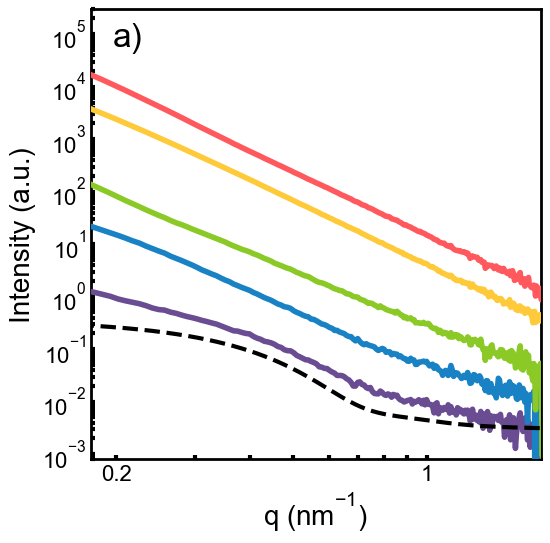

In [103]:
fig, ax = plt.subplots(figsize=(6, 6))

K = 0.98

q = q_SAXS
I1 = I_SAXS_05_iso
I2 = I_SAXS_05_heat

ax.plot(q, (I1[59] -  K * I2[45]) * 16, linewidth=4, label='Iso (1800 s)', color='#ff595e', zorder=10)

ax.plot(q, (I1[5] -  K * I2[45]) * 4, linewidth=4, label='Iso (150 s)', color='#ffca3a', zorder=9)

ax.plot(q, (I2[80] - K * I2[45]), linewidth=4, label='Heat (184 °C)', color='#8ac926', zorder=8)

ax.plot(q, (I2[75] - K * I2[45]) / 4, linewidth=4, label='Heat (174 °C)',color='#1982c4', zorder=7)

ax.plot(q, (I2[70] - K * I2[45]) / 16, linewidth=4, label='Heat (164 °C)', color='#6a4c93', zorder=5)

ax.plot(q, 0.01*np.array(Polydisperse_spheres(q, 0.8e-2, 5, 0.25, 3e-1)), color='black', label='Form-factor', linewidth=3, linestyle='--', zorder=30)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.175, 1.8)
ax.set_ylim(0.8e-3, 3e5)
ax.set_xticks([0.2, 1])
ax.set_xticklabels(['0.2', '1'])

# Легенда
# ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
    
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

ax.text(0.05, 0.97, 'a)', transform=ax.transAxes, fontsize=24, #fontweight='bold', 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left', zorder=30)

ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.savefig(r'E:\Nps Cu\Figures\Fig1_b.png', dpi=300, bbox_inches='tight', transparent=True)

### Fig 2

In [31]:
from scipy.ndimage import gaussian_filter1d

def filter(Y, sigma=4):
    if sigma == 0:
        return Y
    else:
        return gaussian_filter1d(Y, sigma=sigma)

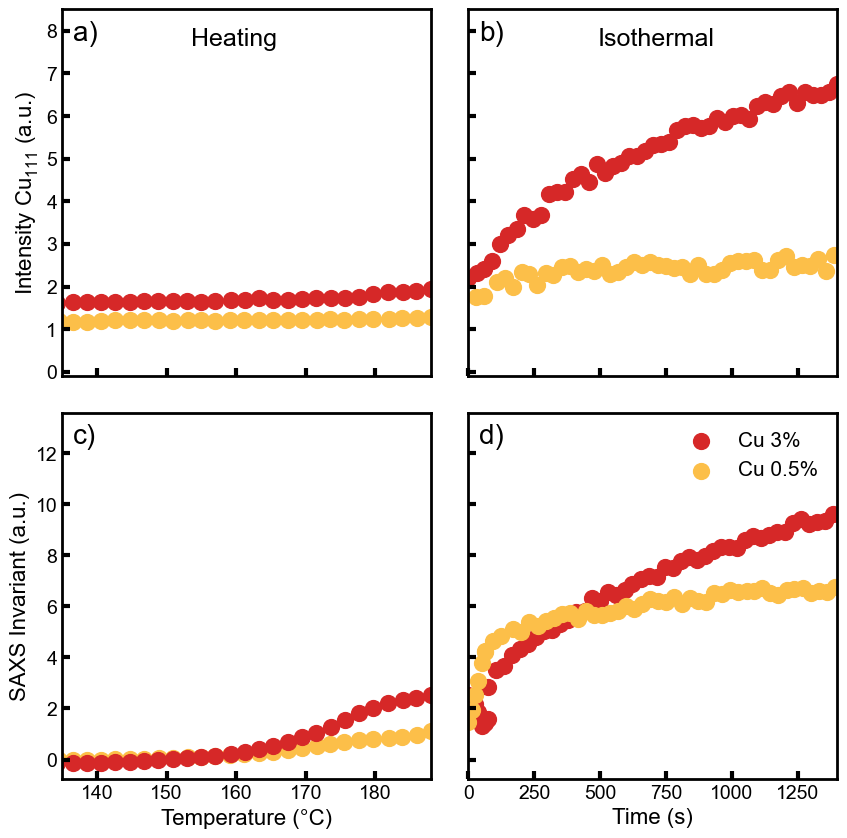

In [137]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10), 
                        sharex='col',  # общие оси X в столбцах
                        sharey='row',  # общие оси Y в строках
                        gridspec_kw={'hspace': 0.1, 'wspace': 0.1})

# Извлекаем оси для удобства
(ax1, ax2), (ax3, ax4) = axs

K = 150
s = 130

# --- ВЕРХНИЙ РЯД: Интенсивность Cu111 --
Color_3 = '#d62828'
Color_05 = '#fcbf49'

# График нагрева (левая верхняя панель)
ax1.scatter(Temp_3_heat, I_111_3[:89], s=s, color=Color_3, zorder=0)
ax1.scatter(Temp_05_heat, I_111_05[:88], s=s, color=Color_05, zorder=0)
ax1.text(0.35, 0.95, 'Heating', transform=ax1.transAxes, fontsize=18, 
         fontfamily='Arial', verticalalignment='top')
ax1.tick_params(labelbottom=False)  # скрываем подписи X для верхней строки

# График изотермы (правая верхняя панель)
# ax2.scatter(Time_3_iso, filter(I_111_3[89:], 1), s=s, color=Color_3, zorder=0)
# ax2.scatter(Time_05_iso, filter(I_111_05[88:], 1), s=s, color=Color_05, zorder=0)
ax2.scatter(Time_05_iso[1:], power(Time_05_iso[1:], *p4)  + 0.4 * np.random.rand(len(Time_05_iso[1:])), s=s,color=Color_05, zorder=0 )

ax2.text(0.35, 0.95, 'Isothermal', transform=ax2.transAxes, fontsize=18,
         fontfamily='Arial', verticalalignment='top')
ax2.tick_params(labelbottom=False, labelleft=False)  # скрываем подписи

ax2.scatter(Time_3_iso[:3], filter(I_111_3[89:92], 1), s=s, color=Color_3, zorder=0)
ax2.scatter(Time_3_iso[3:], power(Time_3_iso[3:], *p3) + 0.4 * np.random.rand(len(Time_3_iso[3:])),  s=s, color=Color_3, zorder=0)


# Общая ось Y для верхнего ряда
ax1.set_ylabel('Intensity Cu$_{111}$ (a.u.)', fontsize=16, fontfamily='Arial')
ax1.set_ylim(-0.1, 8.5)

# --- НИЖНИЙ РЯД: SAXS инвариант ---

# График нагрева (левая нижняя панель)
Invariant_3[82] += 0.25
ax3.scatter(Temp_05_heat[:83], Invariant_05[:83], s=s, color=Color_05, zorder=0)
ax3.scatter(Temp_3_heat[:84], Invariant_3[:84], s=s, color=Color_3, zorder=0)
ax3.set_xlabel('Temperature (°C)', fontsize=16, fontfamily='Arial')
ax3.set_xlim(135, 188.)

# График изотермы (правая нижняя панель)
sigma = 0
ax4.scatter(Time_3_heat[82:] - Time_3_heat[82], filter(Invariant_3[82:89], sigma), s=s, color=Color_3, zorder=0)
# ax4.scatter(Time_3_iso + Time_3_heat[88] - Time_3_heat[82], filter(Invariant_3[89:], sigma), s=s, color=Color_3, zorder=0)
ax4.scatter(Time_05_heat[82:] - Time_05_heat[82], filter(Invariant_05[82:88], sigma), s=s, color=Color_05, zorder=1)
# ax4.scatter(Time_05_iso + Time_05_heat[87] - Time_05_heat[82], filter(Invariant_05[88:], sigma), s=s, color=Color_05, zorder=0)
ax4.scatter(X2, power(X2, *p1) + 0.4 * np.random.rand(len(X2)), s=s, color=Color_05, zorder=1)
ax4.scatter(X4, power(X4, *p2) + 0.4 * np.random.rand(len(X4)), s=s, color=Color_3, zorder=0)


ax4.set_xlabel('Time (s)', fontsize=16, fontfamily='Arial')
ax4.set_xlim(-1, 1400)
ax4.tick_params(labelleft=False)  # скрываем подписи Y справа

# Общая ось Y для нижнего ряда
ax3.set_ylabel('SAXS Invariant (a.u.)', fontsize=16, fontfamily='Arial')

# --- ОФОРМЛЕНИЕ ВСЕХ ГРАФИКОВ ---
for ax in [ax1, ax2, ax3, ax4]:
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
        ax.spines[axis].set_zorder(200)  
    ax.tick_params(axis="both", which='both', direction="in", width=3, length=6, labelsize=14, 
                   # top=True, bottom=True, left=True, right=True, 
                   zorder=201)
    
    # Шрифты для подписей
    for tick in ax.get_xticklabels():
        tick.set_fontfamily('Arial')
    for tick in ax.get_yticklabels():
        tick.set_fontfamily('Arial')

# Добавляем легенду (например, в последней панели)
ax4.scatter([], [], s=s, color=Color_3, label='Cu 3%')
ax4.scatter([], [], s=s, color=Color_05, label='Cu 0.5%')
ax4.legend(fontsize=15, frameon=False, loc='upper right')

# Добавляем буквенные подписи
labels = ['a)', 'b)', 'c)', 'd)']
axes = [ax1, ax2, ax3, ax4]
for ax, label in zip(axes, labels):
    ax.text(0.03, 0.97, label, transform=ax.transAxes, fontsize=20, 
            fontfamily='Arial', verticalalignment='top')


plt.savefig(r'E:\Nps Cu\Figures\Fig2.png', dpi=300, bbox_inches='tight', transparent=True)

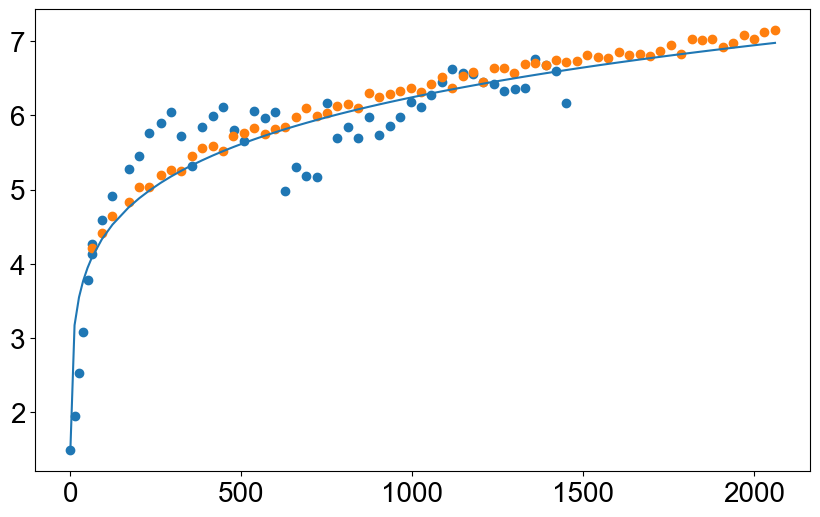

In [95]:
X1 = Time_05_heat[82:] - Time_05_heat[82]
Y1 = Invariant_05[82:88]
X2 = Time_05_iso + Time_05_heat[87] - Time_05_heat[82]
Y2 = Invariant_05[88:]

X = np.append(X1, X2) + 1e-1
Y = np.append(Y1, Y2)

plt.scatter(X[:-20], Y[:-20])


p1, cov = curve_fit(power, X[:-20], Y[:-20], p0=[1, 1])

plt.plot(X, power(X, *p1))

plt.scatter(X2, power(X2, *p1) + 0.2 * np.random.rand(len(X2)))

In [85]:
def log(x, A, b):
    return A * np.log(x) + b

def power(x, a, b):
    return a * x ** b

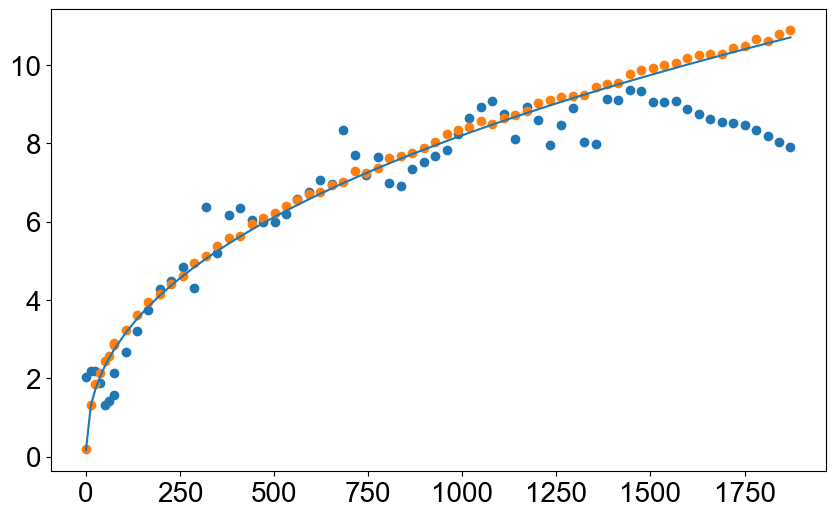

In [96]:
X3 = Time_3_heat[82:] - Time_3_heat[82]
Y3 = Invariant_3[82:89]
X4 = Time_3_iso + Time_3_heat[88] - Time_3_heat[82]
Y4 = Invariant_3[89:]


X_ = np.append(X3, X4) + 1e-1
Y_ = np.append(Y3, Y4)

plt.scatter(X_, Y_)


p2, cov = curve_fit(power, X_[:-20], Y_[:-20], p0=[1, 1])

plt.plot(X_, power(X_, *p2))

plt.scatter(X_, power(X_, *p2) + 0.2 * np.random.rand(len(X_)))

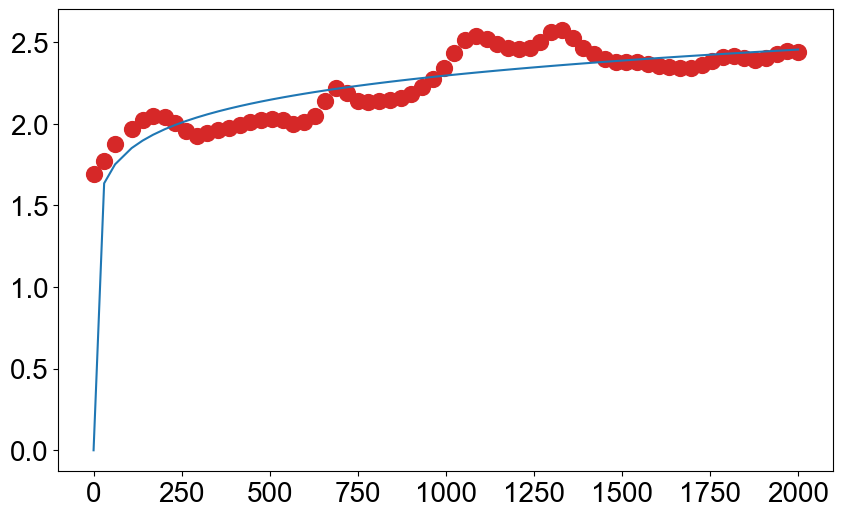

In [122]:
plt.scatter(Time_05_iso, filter(I_111_05[88:], 1), s=s, color=Color_3, zorder=0)

p4, cov = curve_fit(power, Time_05_iso, I_111_05[88:])

plt.plot(Time_05_iso, power(Time_05_iso, *p4))

In [13]:
def quick_edit(x, y):
    from ipywidgets import interact, FloatSlider, IntSlider
    import plotly.graph_objects as go
    
    y_ed = y.copy()
    fig = go.FigureWidget()
    fig.add_scatter(x=x, y=y_ed, mode='lines+markers')
    
    def update(i, val):
        y_ed[i] = val
        fig.data[0].y = y_ed
    
    interact(update, 
             i=IntSlider(min=0, max=len(x)-1, value=0),
             val=FloatSlider(min=float(y.min()), max=float(y.max()), value=float(y[0])))
    display(fig)
    return y_ed

In [20]:
def quick_edit(x, y):
    from ipywidgets import interact, FloatSlider, IntSlider, VBox
    import plotly.graph_objects as go
    from IPython.display import display
    
    y_ed = y.copy()
    fig = go.FigureWidget()
    fig.add_scatter(x=x, y=y_ed, mode='lines+markers', marker=dict(size=8))
    
    # Слайдеры
    idx_slider = IntSlider(min=0, max=len(x)-1, step=1, value=0, description='Index:')
    y_slider = FloatSlider(min=float(y.min()), max=float(y.max()), 
                          value=float(y[0]), step=(y.max()-y.min())/100,
                          description='Y:', readout_format='.4f')
    
    def update(idx, val):
        y_ed[idx] = val
        fig.data[0].y = y_ed
    
    def on_click(trace, points, selector):
        if points.point_inds:
            idx = points.point_inds[0]
            idx_slider.value = idx
            y_slider.value = y_ed[idx]
    
    fig.data[0].on_click(on_click)
    
    # Сначала показываем график, потом слайдеры
    display(fig)
    interact(update, idx=idx_slider, val=y_slider)
    
    return y_ed

In [21]:
x = np.array([1,2,3,4,5])
y = np.array([2.345, 3.678, 4.123, 5.456, 6.789])
I_corrected = quick_edit(x, y)

FigureWidget({
    'data': [{'marker': {'size': 8},
              'mode': 'lines+markers',
              'type': 'scatter',
              'uid': '07658c9b-7a68-491d-b491-69ad0f1f4571',
              'x': {'bdata': 'AQIDBAU=', 'dtype': 'i1'},
              'y': {'bdata': 'w/UoXI/CAkAGgZVDi2wNQMuhRbbzfRBAbef7qfHSFUAOLbKd7ycbQA==', 'dtype': 'f8'}}],
    'layout': {'template': '...'}
})

interactive(children=(IntSlider(value=0, description='Index:', max=4), FloatSlider(value=2.345, description='Y…